In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('churn.csv')
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
635,7207-RMRDB,Female,0,Yes,Yes,65,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,6985.65,Yes
5779,2237-ZFSMY,Female,0,No,No,39,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,No,One year,Yes,Electronic check,95.55,3692.85,Yes
2272,8064-RAVOH,Male,0,No,Yes,1,Yes,No,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,49.85,49.85,No
4082,0112-QWPNC,Male,0,Yes,No,49,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,No,Electronic check,84.35,4059.35,Yes
4558,8063-GBATB,Female,1,No,No,27,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.25,2287.25,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [7]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [8]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [9]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [10]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [11]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [12]:
df['MonthlyCharges'].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64

In [13]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [14]:
df['OnlineSecurity'].value_counts() 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [15]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [16]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [17]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [18]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [19]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [20]:
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [21]:
df['customerID'].value_counts()

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

In [22]:
redundant_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for i in redundant_cols:
    df[i]=df[i].replace({'No phone service':'No','No internet service':'No'})


In [23]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4076,1325-USMEC,Male,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,No,Two year,Yes,Credit card (automatic),99.35,6944.5,No
1835,8356-WUAOJ,Female,0,Yes,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.00,45,No
6908,1750-CSKKM,Male,0,No,Yes,9,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,No,Electronic check,55.35,449.75,Yes
6131,1095-JUDTC,Female,1,No,No,47,Yes,Yes,Fiber optic,No,Yes,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,95.05,4504.55,Yes
5152,8807-OPMBM,Female,0,Yes,Yes,55,Yes,Yes,No,No,No,No,No,No,No,Two year,Yes,Credit card (automatic),25.65,1388,No


In [24]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [25]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

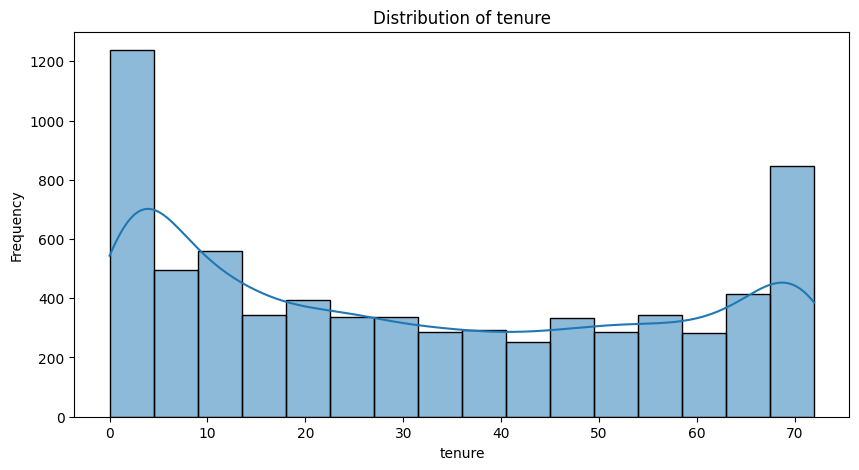

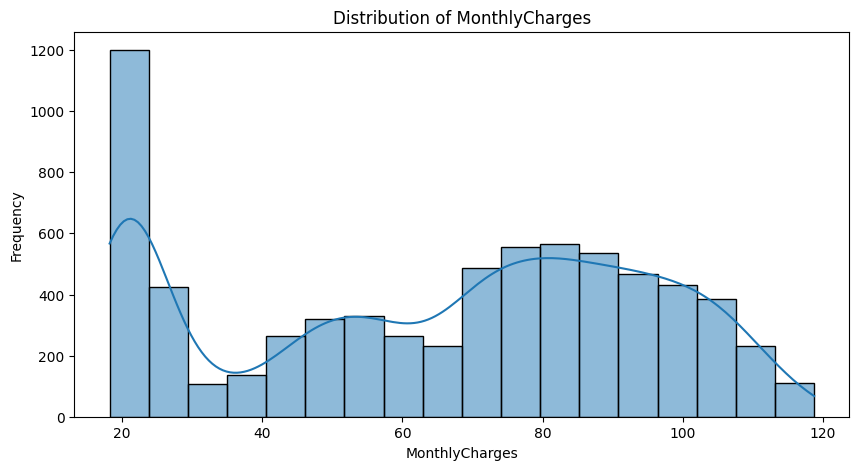

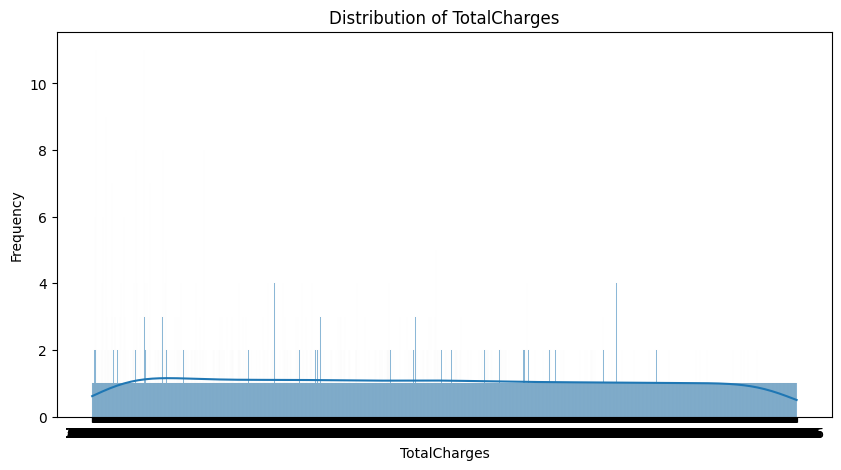

In [26]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i in numerical_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(df[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.show()

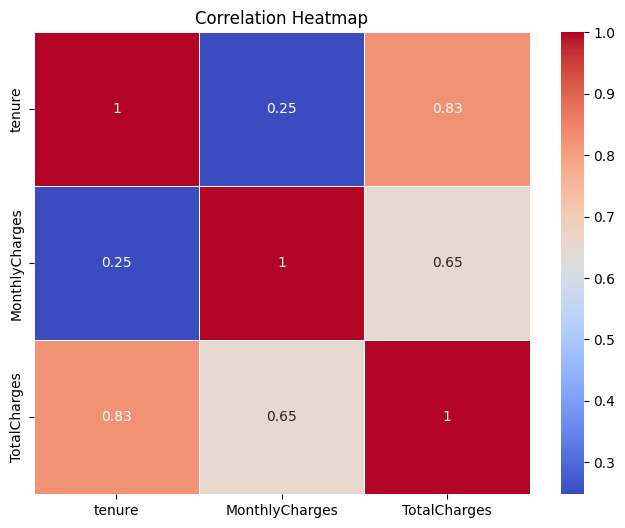

In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [28]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [29]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
735,7595-EHCDL,Male,0,Yes,Yes,32,No,No,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Credit card (automatic),50.60,1653.45,0
6559,1427-VERSM,Female,0,Yes,No,56,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,98.70,5669.50,0
6906,9945-PSVIP,Female,0,Yes,Yes,25,Yes,No,No,No,No,No,No,No,No,Two year,Yes,Mailed check,18.70,383.65,0
2808,6645-MXQJT,Male,0,Yes,Yes,2,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,97.10,184.15,0
1410,7024-OHCCK,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,170.85,1


In [30]:
df=df.drop('customerID', axis=1)

In [31]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]
for i in binary_cols:
    df[i]=df[i].map({'Yes':1,'No':0})


In [32]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3899,Female,1,1,0,52,1,1,Fiber optic,1,1,1,0,1,1,Month-to-month,1,Electronic check,109.10,5647.95,0
5779,Female,0,0,0,39,1,0,Fiber optic,1,0,1,1,1,0,One year,1,Electronic check,95.55,3692.85,1
5048,Female,1,1,0,54,1,0,Fiber optic,0,0,1,1,1,1,One year,1,Electronic check,99.10,5437.10,0
3439,Male,1,1,0,72,1,1,Fiber optic,0,1,1,0,1,1,Two year,1,Bank transfer (automatic),104.15,7689.95,1
5414,Male,0,0,0,64,1,1,Fiber optic,0,1,0,1,1,1,One year,1,Credit card (automatic),105.65,6903.10,1


In [33]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1881,Male,0,0,0,26,0,0,DSL,1,1,0,0,0,1,Month-to-month,1,Bank transfer (automatic),44.65,1156.55,0
1329,Female,0,1,0,72,1,0,No,0,0,0,0,0,0,Two year,0,Bank transfer (automatic),19.40,1496.45,0
3374,Female,1,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,0,Mailed check,54.85,104.20,1
4407,Male,0,0,1,8,1,0,No,0,0,0,0,0,0,Month-to-month,0,Mailed check,20.35,178.70,0
3991,Female,0,0,0,4,1,1,Fiber optic,0,1,0,1,0,1,Month-to-month,1,Electronic check,93.50,362.20,1


In [34]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [35]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6559,Female,0,1,0,56,1,0,Fiber optic,0,0,1,1,1,1,Month-to-month,1,Electronic check,98.70,5669.50,0
4406,Female,0,0,0,37,1,1,DSL,1,1,1,1,1,0,Month-to-month,1,Credit card (automatic),78.90,2976.95,0
4000,Female,1,0,0,39,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,Electronic check,99.75,4036.00,0
2626,Female,0,1,0,60,0,0,DSL,1,1,1,0,0,1,One year,0,Electronic check,50.05,2911.50,0
3173,Female,0,1,0,17,1,0,No,0,0,0,0,0,0,One year,0,Mailed check,19.35,307.00,0


In [36]:
cols=['gender', 'Contract', 'InternetService', 'PaymentMethod']
df=pd.get_dummies(df,columns=cols,drop_first=True)

In [37]:
df.isnull().sum()

SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
MultipleLines                             0
OnlineSecurity                            0
OnlineBackup                              0
DeviceProtection                          0
TechSupport                               0
StreamingTV                               0
StreamingMovies                           0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
gender_Male                               0
Contract_One year                         0
Contract_Two year                         0
InternetService_Fiber optic               0
InternetService_No                        0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check  

In [38]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [39]:
df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3424,0,0,0,10,1,0,0,0,0,0,1,1,1,89.50,863.10,1,True,False,False,True,False,False,True,False
2493,0,1,0,6,1,1,0,1,0,0,0,1,1,90.75,512.25,0,False,False,False,True,False,False,True,False
4149,0,1,0,71,0,0,0,1,0,0,1,1,0,49.35,3515.25,1,True,False,True,False,False,False,True,False
6391,0,1,1,38,1,1,0,1,1,0,1,1,0,78.95,2862.55,0,True,True,False,False,False,True,False,False
7008,1,0,0,3,1,1,0,0,0,0,0,0,1,75.05,256.25,1,False,False,False,True,False,True,False,False


In [40]:
cols=['gender_Male','Contract_One year','Contract_Two year','InternetService_Fiber optic','InternetService_No','PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check','PaymentMethod_Mailed check']
df=pd.get_dummies(df,columns=cols,drop_first=True)

In [41]:
df.sample(5)   

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male_True,Contract_One year_True,Contract_Two year_True,InternetService_Fiber optic_True,InternetService_No_True,PaymentMethod_Credit card (automatic)_True,PaymentMethod_Electronic check_True,PaymentMethod_Mailed check_True
5177,1,1,0,36,1,1,0,0,0,0,0,1,1,84.10,3021.60,1,True,False,False,True,False,False,True,False
6607,0,0,1,1,0,0,0,0,0,0,0,0,1,25.30,25.30,1,True,False,False,False,False,False,True,False
4600,0,1,1,56,1,1,1,1,1,1,1,1,0,115.85,6567.90,0,True,False,True,True,False,False,False,True
4949,0,0,0,5,0,0,0,1,0,0,1,1,1,51.00,305.95,1,True,False,False,False,False,False,False,True
6208,0,1,0,61,1,1,1,1,1,1,0,1,1,80.80,4860.85,0,True,False,True,False,False,False,False,False


In [42]:
df=df.astype('int')

In [43]:
df.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male_True,Contract_One year_True,Contract_Two year_True,InternetService_Fiber optic_True,InternetService_No_True,PaymentMethod_Credit card (automatic)_True,PaymentMethod_Electronic check_True,PaymentMethod_Mailed check_True
6221,0,0,0,26,1,0,0,0,0,0,0,0,1,19,471,0,1,1,0,0,1,0,0,0
6646,0,1,1,51,1,0,0,0,0,0,0,0,0,19,997,0,1,1,0,0,1,0,0,1
3302,0,0,0,31,1,1,0,1,1,0,1,1,1,103,3066,1,1,1,0,1,0,0,1,0
2188,0,0,0,29,0,0,0,0,0,1,0,0,1,31,926,0,0,0,0,0,0,0,1,0
868,0,1,0,59,1,1,0,0,0,0,0,1,0,85,5084,1,1,1,0,1,0,0,1,0


In [44]:
from sklearn.model_selection import train_test_split
X=df.drop('Churn', axis=1)
Y=df['Churn']

Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42)

In [45]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
Xtrain[numerical_cols]=scaler.fit_transform(Xtrain[numerical_cols])
Xtest[numerical_cols]=scaler.transform(Xtest[numerical_cols])

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model_log=LogisticRegression(max_iter=1000)
model_log.fit(Xtrain,Ytrain)
Ypred_log=model_log.predict(Xtest)
print("Logistic Regression Accuracy:", accuracy_score(Ytest, Ypred_log))
print("Logistic Regression Classification Report:\n", classification_report(Ytest, Ypred_log))

Logistic Regression Accuracy: 0.8218594748048261
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model_knn=KNeighborsClassifier()
model_knn.fit(Xtrain, Ytrain)
Ypred_knn=model_knn.predict(Xtest)
print("KNN Accuracy:", accuracy_score(Ytest, Ypred_knn))
print("KNN Classification Report:\n", classification_report(Ytest, Ypred_knn))

KNN Accuracy: 0.7792760823278921
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85      1036
           1       0.59      0.53      0.56       373

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



In [48]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model_svc=SVC()
model_svc.fit(Xtrain, Ytrain)
Ypred_svc=model_svc.predict(Xtest)
print("SVC Accuracy:", accuracy_score(Ytest, Ypred_svc))
print("SVC Classification Report:\n", classification_report(Ytest, Ypred_svc))

SVC Accuracy: 0.8119233498935415
SVC Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
model_dt=DecisionTreeClassifier()
model_dt.fit(Xtrain, Ytrain)
Ypred_dt=model_dt.predict(Xtest)
print("Decision Tree Accuracy:", accuracy_score(Ytest, Ypred_dt))
print("Decision Tree Classification Report:\n", classification_report(Ytest, Ypred_dt))

Decision Tree Accuracy: 0.723207948899929
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81      1036
           1       0.48      0.45      0.46       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



In [50]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
model_nb=GaussianNB()
model_nb.fit(Xtrain, Ytrain)
Ypred_nb=model_nb.predict(Xtest)
print("Naive Bayes Accuracy:", accuracy_score(Ytest, Ypred_nb)) 
print("Naive Bayes Classification Report:\n", classification_report(Ytest, Ypred_nb))

Naive Bayes Accuracy: 0.7601135557132718
Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.81      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [51]:
columns=X.columns.tolist()
import joblib
joblib.dump(model_log,'logistic_model.pkl')
joblib.dump(columns,'model_columns.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [52]:
X.sample(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male_True,Contract_One year_True,Contract_Two year_True,InternetService_Fiber optic_True,InternetService_No_True,PaymentMethod_Credit card (automatic)_True,PaymentMethod_Electronic check_True,PaymentMethod_Mailed check_True
2761,1,0,0,10,0,0,0,0,0,0,0,1,1,34,329,0,0,0,0,0,0,1,0
3903,0,0,0,53,1,0,0,1,0,1,0,0,1,80,4348,1,0,0,1,0,0,0,1
6704,0,1,1,59,1,1,0,1,1,0,1,1,1,106,6256,0,1,0,1,0,0,1,0
6508,0,1,1,42,1,1,0,0,0,0,1,1,1,94,4186,0,0,0,1,0,0,1,0
6388,0,0,0,1,1,0,0,0,0,0,0,0,0,20,20,0,0,0,0,1,0,0,1


In [53]:
X.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   SeniorCitizen                               7043 non-null   int64
 1   Partner                                     7043 non-null   int64
 2   Dependents                                  7043 non-null   int64
 3   tenure                                      7043 non-null   int64
 4   PhoneService                                7043 non-null   int64
 5   MultipleLines                               7043 non-null   int64
 6   OnlineSecurity                              7043 non-null   int64
 7   OnlineBackup                                7043 non-null   int64
 8   DeviceProtection                            7043 non-null   int64
 9   TechSupport                                 7043 non-null   int64
 10  StreamingTV                         

In [57]:
from sklearn.model_selection import cross_val_score
models={
    'Logistic Regression': model_log,
    'KNN': model_knn,
    'SVC': model_svc,
    'Decision Tree': model_dt,
    'Naive Bayes': model_nb
}
for i,model in models.items():
    scores=cross_val_score(model,Xtrain,Ytrain,cv=5)
    print(f'{i} Cross-Validation Scores: {scores}')
    print(f'{i} Average Cross-Validation Score: {scores.mean()}')

Logistic Regression Cross-Validation Scores: [0.81188997 0.80745342 0.7985803  0.78793256 0.80017762]
Logistic Regression Average Cross-Validation Score: 0.8012067750878249
KNN Cross-Validation Scores: [0.76929902 0.76397516 0.75865129 0.77373558 0.76110124]
KNN Average Cross-Validation Score: 0.7653524580733521
SVC Cross-Validation Scores: [0.80567879 0.8065661  0.78704525 0.79148181 0.79840142]
SVC Average Cross-Validation Score: 0.7978346763834887
Decision Tree Cross-Validation Scores: [0.71606034 0.7133984  0.73114463 0.73558119 0.72912966]
Decision Tree Average Cross-Validation Score: 0.7250628446606072
Naive Bayes Cross-Validation Scores: [0.75244011 0.7444543  0.74889086 0.72138421 0.76021314]
Naive Bayes Average Cross-Validation Score: 0.7454765240716721
